# Arabic Handwritten Document Understanding & RAG Pipeline

This notebook validates the CPU-only pipeline from full-page handwriting through retrieval and Groq-backed grounded answer generation using the existing implementations in `src/`. It processes a small streaming sample.

## 0. Project setup

The root is discovered by walking upward, so paths remain relative when the notebook is opened from either the repository root or `notebooks/`.

In [1]:
from pathlib import Path
import platform
import sys

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "src").exists():
    raise FileNotFoundError("Could not locate the project root containing src/.")
sys.path.insert(0, str(PROJECT_ROOT))
DEVICE = "cpu"
print(f"Project root: {PROJECT_ROOT}")
print(f"Python version: {platform.python_version()}")
print(f"Selected device: {DEVICE}")

Project root: C:\Users\workstation\Downloads\pp
Python version: 3.10.21
Selected device: cpu


## 1. Imports

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
from datasets import load_dataset
from PIL import Image, ImageDraw

from src.cv.line_detector import LineDetector
from src.ocr.muharaf_ocr import MuharafOCR
from src.rag.preprocessing import clean_arabic_text
from src.rag.chunking import create_chunks
from src.rag.embeddings import ArabicEmbeddingModel
from src.rag.vectorstore import ChromaVectorStore
from src.rag.retriever import ArabicRetriever

c:\Users\workstation\.conda\envs\env_cv_modern\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Initialize CV and OCR

The configured Muharaf-trained Kraken model is required; this notebook does not silently switch to another detector.

In [3]:
SEGMENTATION_MODEL = PROJECT_ROOT / "models" / "muharaf_seg_best.mlmodel"
if not SEGMENTATION_MODEL.is_file():
    raise FileNotFoundError(
        f"Missing segmentation model: {SEGMENTATION_MODEL}. "
        "Place muharaf_seg_best.mlmodel in models/."
    )

detector = LineDetector(
    backend="kraken",
    model_path=str(SEGMENTATION_MODEL),
    device=DEVICE,
)
ocr = MuharafOCR()
print("Initialized Kraken line segmentation and Muharaf OCR on CPU.")

Fetching 57 files: 100%|██████████| 57/57 [00:00<00:00, 6124.01it/s]

Initialized Kraken line segmentation and Muharaf OCR on CPU.



C:\Users\workstation\.cache\huggingface\hub\models--sdkv2--muharaf-arabic-ocr\snapshots\e75d511257d6a0c0ffdede92308e8e022c79e1c5\submission_code\torch_models.py:175: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_encoder_layers)


## 3. Load Muharaf Public Pages

Streaming avoids downloading the complete dataset. Each retained sample preserves its image, ground-truth text, page identifier, source, and original record.

In [4]:
N_PAGES = 20
DATASET_NAME = "TheRealOKAI/muharaf-public-pages"
pages_stream = load_dataset(DATASET_NAME, split="train", streaming=True)

def _first_present(sample, names):
    for name in names:
        if name in sample and sample[name] is not None:
            return sample[name]
    return None

pages = []
for page_index, sample in enumerate(pages_stream):
    image = _first_present(sample, ("image", "img", "page_image"))
    ground_truth = _first_present(sample, ("text", "transcription", "ground_truth", "label"))
    if image is None or ground_truth is None:
        raise KeyError(
            "Dataset sample must contain image and text; "
            f"available fields: {sorted(sample.keys())}"
        )
    if not isinstance(image, Image.Image):
        image = Image.fromarray(image)
    pages.append({
        "page_id": str(sample.get("id", sample.get("page_id", page_index))),
        "source": DATASET_NAME,
        "image": image.convert("RGB"),
        "ground_truth": str(ground_truth),
        "raw_sample": sample,
    })
    if len(pages) >= N_PAGES:
        break
if not pages:
    raise RuntimeError("The streaming dataset returned no usable pages.")
print(f"Collected {len(pages)} page(s) from {DATASET_NAME} (streaming=True).")

Collected 20 page(s) from TheRealOKAI/muharaf-public-pages (streaming=True).


## 4. Visualize one page

This view is shown before segmentation or OCR.

Page ID: 2015 5-03 El-Khouri_Letter to Jennie Jabaley from Lebanon Oct18 1960_1
Ground-truth characters: 808


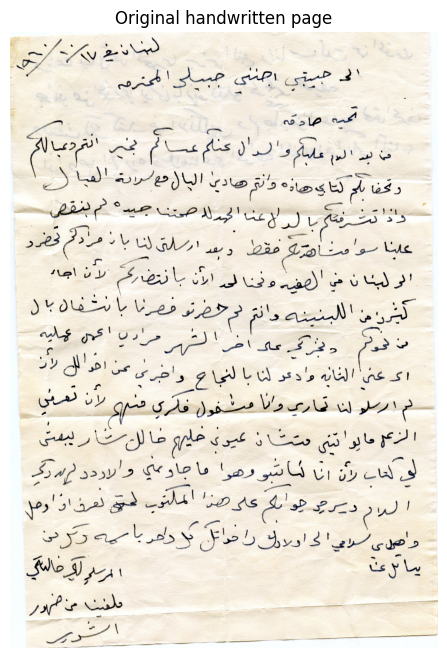

In [5]:
preview_page = pages[0]
print(f"Page ID: {preview_page['page_id']}")
print(f"Ground-truth characters: {len(preview_page['ground_truth'])}")
plt.figure(figsize=(12, 8))
plt.imshow(preview_page["image"])
plt.axis("off")
plt.title("Original handwritten page")
plt.show()

## 5. Line segmentation

Detected lines: 18


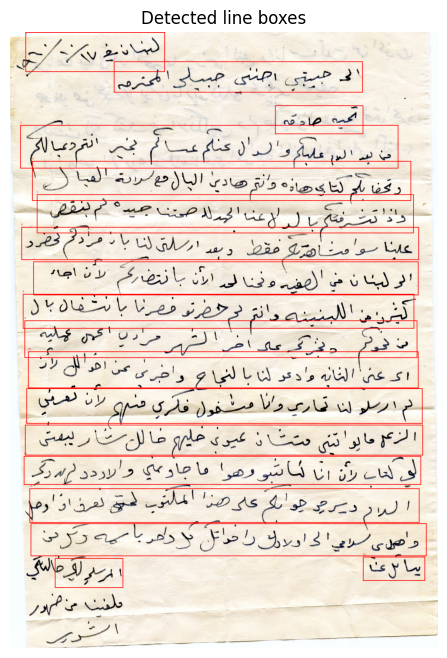

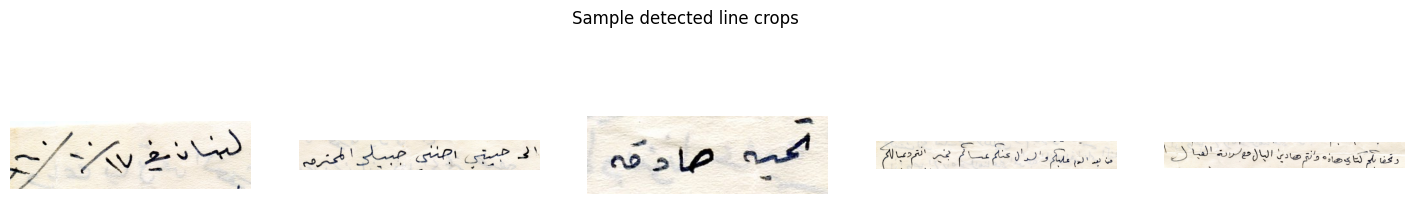

In [6]:
preview_lines = detector.detect(preview_page["image"], return_crops=True)
print(f"Detected lines: {len(preview_lines)}")
boxed_page = preview_page["image"].copy()
draw = ImageDraw.Draw(boxed_page)
for line_index, line in enumerate(preview_lines):
    x1, y1, x2, y2 = line["bbox"]
    draw.rectangle((x1, y1, x2, y2), outline="red", width=3)
    draw.text((x1, max(0, y1 - 16)), str(line_index), fill="red")
plt.figure(figsize=(12, 8))
plt.imshow(boxed_page)
plt.axis("off")
plt.title("Detected line boxes")
plt.show()
if preview_lines:
    figure, axes = plt.subplots(1, min(5, len(preview_lines)), figsize=(18, 3))
    axes = [axes] if len(preview_lines) == 1 else axes
    for axis, line in zip(axes, preview_lines[:5]):
        axis.imshow(line["crop"])
        axis.axis("off")
    figure.suptitle("Sample detected line crops")
    plt.show()

## 6. OCR

In [7]:
preview_text = ocr.recognize_page(preview_lines)
print("OCR text:\n")
print(preview_text)
print("\nGround-truth text:\n")
print(preview_page["ground_truth"])

OCR text:

طبنان فيي ١/٠
الى جيي اجني جبيل المحترمه
الحية صادقه
من بعد الوم عليكم والسدال عنكم عساكم بخير انتم وعبالكم
وتحضا بلكم كتابي هاذه وانتم هادين البال مع نسراة العبال
واذ تشرفتكم بالدال عنا الحدله صحتنا جيده لم بنقص
علينا سوامشاخدته حقط وبعد ارسلتى لنا باز مرادكم لحضرد
الولبنان في الصفيه ونحنا لحد ارأن بنتضارم لان اجاء
كثير من اللبنينه وانتم لم حضرتو فصرنا بانشغال بال
من ولكم وبخرر على اخر الشهر مرادي اعم عليه
اى عني الثانيه وادعو لنا بالنجاح واخبرني عن اخولل لا
لم ارسلالنا تحاري وانا مشخول فري منه لان تعرفي
الزعى مايو الين متشان عيون خليهم خالك شا يبعت
الى كتات رن انا لتاننو وهوا ما جاد مي والاددد لبدكر
السدام ديرح جواكم على هذا الملتوب لح لعرث اذ ادصل
واهل ى سدامي الى اولاك راخواتل ك داحد باه دكر من
يسالل عنا
الرسلوليه

Ground-truth text:

لبنان في ١٧/١٠/١٩٦٠
الى حبييتي اجنني جبيلي المحترمه
تحية صادقه
من بعد السلام عليكم والسوال عنكم عساكم بخير انتم وعيالكم
وتحفا بكم كتابي هاذه وانتم هادين البال مع سلامة العيال
واذا تشرفتم بالسؤال عنا الحمدلله صحتنا جيده لم ينقص
علينا سوا مشا

## 7. OCR evaluation

This page-level CER is an evaluation on the selected sample pages only; it is not a claim about generalization.

In [8]:
def character_error_rate(reference, hypothesis):
    reference, hypothesis = str(reference), str(hypothesis)
    previous = list(range(len(hypothesis) + 1))
    for row, ref_char in enumerate(reference, start=1):
        current = [row]
        for column, hyp_char in enumerate(hypothesis, start=1):
            current.append(min(
                current[-1] + 1,
                previous[column] + 1,
                previous[column - 1] + (ref_char != hyp_char),
            ))
        previous = current
    return previous[-1] / max(1, len(reference))

ocr_records = []
for page in pages:
    detected_lines = detector.detect(page["image"], return_crops=True)
    recognized_text = ocr.recognize_page(detected_lines)
    ocr_records.append({
        "page_id": page["page_id"],
        "detected_lines": len(detected_lines),
        "ground_truth_length": len(page["ground_truth"]),
        "ocr_text_length": len(recognized_text),
        "cer": character_error_rate(page["ground_truth"], recognized_text),
        "ocr_text": recognized_text,
    })
ocr_results = pd.DataFrame(ocr_records)
display(ocr_results[["page_id", "detected_lines", "ground_truth_length", "ocr_text_length", "cer"]])
print(f"Mean CER on selected sample pages: {ocr_results['cer'].mean():.4f}")

,page_id,detected_lines,ground_truth_length,ocr_text_length,cer
0,2015 5-03 El-Khouri_Letter to Jennie Jabaley f...,18,808,727,0.202970
1,2015 5-07 El-Khouri_Letter to Joseph from Leba...,21,852,817,0.150235
2,2015 5-07b El-Khouri_Letter to Joseph from Leb...,16,286,261,0.363636
3,2015 5-07b El-Khouri_Letter to Joseph from Leb...,16,395,362,0.248101
4,2015 5-08b El-Khouri_Letter to Joseph from Leb...,19,1144,1100,0.138986
5,2015 5-08b El-Khouri_Letter to Joseph from Leb...,20,1212,1140,0.133663
6,2015 5-08c El-Khouri_Letter to Joseph from Leb...,21,920,840,0.200000
7,2015 5-09b El-Khouri_Letter to Joseph from Leb...,21,724,694,0.211326
8,2015 5-13 El-Khouri_Letter to Joseph from Leba...,18,913,852,0.167579
9,2015 5-13b El-Khouri_Letter to Joseph from Leb...,19,968,853,0.324380


Mean CER on selected sample pages: 0.2621


## 8. RAG preprocessing

The existing Arabic cleaning and chunking functions are used, with source, page, and chunk metadata retained.

In [9]:
chunk_records = []
for record in ocr_records:
    cleaned_text = clean_arabic_text(record["ocr_text"])
    chunks = create_chunks(cleaned_text) if cleaned_text else []
    for chunk_id, chunk_text in enumerate(chunks):
        chunk_records.append({
            "text": chunk_text,
            "source": DATASET_NAME,
            "page_id": record["page_id"],
            "chunk_id": chunk_id,
        })
if not chunk_records:
    raise RuntimeError("No OCR chunks were produced; cannot build the retrieval index.")
display(pd.DataFrame(chunk_records)[["source", "page_id", "chunk_id", "text"]].head(10))

,source,page_id,chunk_id,text
0,TheRealOKAI/muharaf-public-pages,2015 5-03 El-Khouri_Letter to Jennie Jabaley f...,0,طبنان فيي ١/٠ الى جيي اجني جبيل المحترمه الحية...
1,TheRealOKAI/muharaf-public-pages,2015 5-03 El-Khouri_Letter to Jennie Jabaley f...,1,اعم عليه اى عني الثانيه وادعو لنا بالنجاح واخب...
2,TheRealOKAI/muharaf-public-pages,2015 5-07 El-Khouri_Letter to Joseph from Leba...,0,رسالة يرميي في ١ كلون الاول عمي العزيز اواعيدك...
3,TheRealOKAI/muharaf-public-pages,2015 5-07 El-Khouri_Letter to Joseph from Leba...,1,الجد في هذا التهاد مرورين بذالك لانهما يخبران ...
4,TheRealOKAI/muharaf-public-pages,2015 5-07 El-Khouri_Letter to Joseph from Leba...,2,. حالي ميك فهنم بانواع ان يعيمل متله وعمتي الر...
5,TheRealOKAI/muharaf-public-pages,2015 5-07b El-Khouri_Letter to Joseph from Leb...,0,شر وابهبر عيد الميلاا بالصحة غليكم بناد رب الك...
6,TheRealOKAI/muharaf-public-pages,2015 5-07b El-Khouri_Letter to Joseph from Leb...,0,ععبرين في البتزون ونحن ساكنين في ملك يوسف الشد...
7,TheRealOKAI/muharaf-public-pages,2015 5-08b El-Khouri_Letter to Joseph from Leb...,0,افي استلت عيدكيك الطيفة وهي خمسة عر دولارا. اش...
8,TheRealOKAI/muharaf-public-pages,2015 5-08b El-Khouri_Letter to Joseph from Leb...,1,. بهنيك بها لاغ (شوهوي ولد صالح.. ودائمأ توبن ...
9,TheRealOKAI/muharaf-public-pages,2015 5-08b El-Khouri_Letter to Joseph from Leb...,2,. وان اصلي بانظار الجواب. وفقه الله والم بطرس ...


## 9. Embeddings

The existing wrapper loads `Omartificial-Intelligence-Space/Arabic-Triplet-Matryoshka-V2`; vectors are not printed.

In [10]:
embedding_model = ArabicEmbeddingModel()
chunk_texts = [record["text"] for record in chunk_records]
chunk_embeddings = embedding_model.encode(chunk_texts)
embedding_dimension = len(chunk_embeddings[0]) if chunk_embeddings else 0
print(f"Number of chunks: {len(chunk_texts)}")
print(f"Embedding dimension: {embedding_dimension}")
print(f"Number of documents: {len(pages)}")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 4665.00it/s]


Number of chunks: 48
Embedding dimension: 768
Number of documents: 20


## 10. Chroma vector store

`ChromaVectorStore.add_documents` uses Chroma upsert. Deterministic IDs prevent duplicate documents on reruns.

In [11]:
vector_store = ChromaVectorStore(
    persist_directory=str(PROJECT_ROOT / "data" / "chroma_db"),
    collection_name="handwritten_documents",
)
chunk_ids = [f"{record['page_id']}_chunk_{record['chunk_id']}" for record in chunk_records]
vector_store.add_documents(
    documents=chunk_texts,
    embeddings=chunk_embeddings,
    ids=chunk_ids,
    metadatas=[
        {"source": record["source"], "page_id": record["page_id"], "chunk_id": record["chunk_id"]}
        for record in chunk_records
    ],
)

## 11. Retriever

Retrieval is demonstrated without LLM generation.

In [12]:
retriever = ArabicRetriever(embedding_model=embedding_model, vector_store=vector_store)
example_queries = [
    "ما موضوع هذه الصفحة؟",
    "ما الكلمات المتعلقة بالتاريخ؟",
    "ما المعلومات الرئيسية في النص؟",
]
retrieval_rows = []
for question in example_queries:
    result = retriever.retrieve(question, top_k=3)
    documents = result.get("documents", [[]])[0]
    metadatas = result.get("metadatas", [[]])[0]
    distances = result.get("distances", [[]])[0]
    print(f"\nQuery: {question}")
    for rank, (text, metadata, distance) in enumerate(zip(documents, metadatas, distances), start=1):
        print(f"  {rank}. source={metadata.get('source')} page={metadata.get('page_id')} distance={distance:.4f}")
        print(f"     {text}")
        retrieval_rows.append({
            "question": question, "rank": rank, "source": metadata.get("source"),
            "page_id": metadata.get("page_id"), "chunk_id": metadata.get("chunk_id"),
            "retrieved_text": text, "distance": distance,
        })


Query: ما موضوع هذه الصفحة؟
  1. source=TheRealOKAI/muharaf-public-pages page=2015 5-03 El-Khouri_Letter to Jennie Jabaley from Lebanon Oct18 1960_1 distance=1.6446
     طبنان فيي ١/٠ الى جيي اجني جبيل المحترمه الحية صادقه من بعد الوم عليكم والسدال عنكم عساكم بخير انتم وعبالكم وتحضا بلكم كتابي هاذه وانتم هادين البال مع نسراة العبال واذ تشرفتكم بالدال عنا الحدله صحتنا جيده لم بنقص علينا سوامشاخدته حقط وبعد ارسلتى لنا باز مرادكم لحضرد الولبنان في الصفيه ونحنا لحد ارأن بنتضارم لان اجاء كثير من اللبنينه وانتم لم حضرتو فصرنا بانشغال بال من ولكم وبخرر على اخر الشهر مرادي اعم عليه اى عني الثانيه وادعو لنا بالنجاح واخبرني عن اخولل لا لم ارسلالنا تحاري وانا مشخول فري منه
  2. source=TheRealOKAI/muharaf-public-pages page=2015 5-13 El-Khouri_Letter to Joseph from Lebanon Feb29 1960 1 distance=1.6970
     عن كور ي ٢ شباط٩ ابن عم العزز يوسعا وامراتحفظلكمما بكل قيفد نر من الزمان ارى من واجالي لابل عاطفتي تدفضن وتقول لي علي واجب نحوشخص لحوا ف لحواب حون يجب ان تكتب له فهذها ه يشعورى وعاطفي واشواقي وا

## 12. Retrieval evaluation

This is retrieval inspection, not final RAG answer evaluation.

In [13]:
retrieval_results = pd.DataFrame(retrieval_rows, columns=[
    "question", "rank", "source", "page_id", "chunk_id", "retrieved_text", "distance"
])
display(retrieval_results[["question", "rank", "source", "page_id", "chunk_id", "retrieved_text", "distance"]])

,question,rank,source,page_id,chunk_id,retrieved_text,distance
0,ما موضوع هذه الصفحة؟,1,TheRealOKAI/muharaf-public-pages,2015 5-03 El-Khouri_Letter to Jennie Jabaley f...,0,طبنان فيي ١/٠ الى جيي اجني جبيل المحترمه الحية...,1.644645
1,ما موضوع هذه الصفحة؟,2,TheRealOKAI/muharaf-public-pages,2015 5-13 El-Khouri_Letter to Joseph from Leba...,0,عن كور ي ٢ شباط٩ ابن عم العزز يوسعا وامراتحفظل...,1.696982
2,ما موضوع هذه الصفحة؟,3,TheRealOKAI/muharaf-public-pages,AF_280r,0,AF-280 تاريخه انا الواضح مي اذاه فرا ر زقرة جا...,1.700303
3,ما الكلمات المتعلقة بالتاريخ؟,1,TheRealOKAI/muharaf-public-pages,2015 5-08c El-Khouri_Letter to Joseph from Leb...,2,! سنة سمعيدة! امادها عليكم طلفل المذود بالخير ...,1.667238
4,ما الكلمات المتعلقة بالتاريخ؟,2,TheRealOKAI/muharaf-public-pages,AF_282r,2,، وليان حرر فى ٥ آب ٩٢ ع,1.727438
5,ما الكلمات المتعلقة بالتاريخ؟,3,TheRealOKAI/muharaf-public-pages,AF_296r,3,. واني تقدم لنا ادراق التمفة اللازمة درسم الخت...,1.786529
6,ما المعلومات الرئيسية في النص؟,1,TheRealOKAI/muharaf-public-pages,AF_303r,0,AF-71 ١١ عن ال فخ ٥ ال ٢ سيعدي العم ادا اللاه ...,1.688219
7,ما المعلومات الرئيسية في النص؟,2,TheRealOKAI/muharaf-public-pages,AF_293r,1,. وعند الشثمتع عن الدفع اجروا المملات الجزية و...,1.743556
8,ما المعلومات الرئيسية في النص؟,3,TheRealOKAI/muharaf-public-pages,AF_296r,3,. واني تقدم لنا ادراق التمفة اللازمة درسم الخت...,1.786547


## 13. Current Pipeline

```text
Full handwritten page
        ↓
Kraken line segmentation
        ↓
Muharaf Arabic OCR
        ↓
Arabic text
        ↓
Cleaning
        ↓
Chunking
        ↓
Arabic-Triplet-Matryoshka-V2
        ↓
Chroma
        ↓
Retriever
```

**NEXT STAGE:** `Retriever → grounded Arabic prompt → Groq API → answer + sources`

The current notebook completes the CV → OCR → preprocessing → chunking → embeddings → Chroma → retrieval → Groq generation pipeline.

## 14. Groq grounded answer generation

This final stage uses the existing retriever and `answer_question()` chain. The API key and model are loaded from the repository `.env` file by `src.config`; the key is never written in the notebook.

In [20]:
import importlib
import src.config as config
import src.rag.chain as chain

importlib.reload(config)
importlib.reload(chain)
print(f"Groq model: {config.GROQ_MODEL}")

question = "ما موضوع هذه الوثيقة؟"
answer_result = chain.answer_question(
    question=question,
    retriever=retriever,
    top_k=3,
)


print(f"السؤال: {question}\n")
print(f"الإجابة:\n{answer_result['answer']}\n")
print("المصادر:")
display(pd.DataFrame(answer_result["sources"]))


Groq model: qwen/qwen3.8-27b
السؤال: ما موضوع هذه الوثيقة؟

الإجابة:
بناءً على السياق المسترجع، لا توجد وثيقة واحدة موحدة، بل توجد ثلاثة مقاطع من وثائق مختلفة، وهي:

1.  **المقطع 1:** يبدو أنه جزء من توثيق أو تحرير تاريخي (تاريخ ٥ آب ٩٢).
2.  **المقطع 2:** رسالة شخصية من لبنان (طرابلس) إلى "جيني جبيل" بتاريخ ١٨ أكتوبر ١٩٦٠، تتناول أخبار العائلة والصحة، وتشرح سبب تأخر الحضور إلى لبنان بسبب انشغالهم، مع طلب الدعاء بالنجاح والاستفسار عن إخوة المرسل.
3.  **المقطع 3:** مراسلات إدارية/حكومية تتعلق بـ "الجزية" (ضريبة)، حيث يطلب من الجهة المعنية إجراء الممليات وإرسال النسخ المطلوبة، مع التأكيد على حفظ نسخة في المركز وإرسال النسخة الثانية مع قرار الجزية، بالإضافة إلى طلب إبلاغ الدائرة بأي صعوبات.

**الخلاصة:** لا يمكن تحديد موضوع واحد موحد لجميع المقاطع، فهي تشمل مراسلات شخصية وأخرى إدارية/ضريبية.

المصادر:


,source,page_id,chunk_id
0,TheRealOKAI/muharaf-public-pages,AF_282r,2
1,TheRealOKAI/muharaf-public-pages,2015 5-03 El-Khouri_Letter to Jennie Jabaley f...,0
2,TheRealOKAI/muharaf-public-pages,AF_293r,1
